## Ortam Kurulumu


In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers, callbacks
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import os, glob, random, zipfile, shutil
!pip -q install tf-keras-vis keras-tuner
from tf_keras_vis.gradcam import Gradcam
import keras_tuner as kt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 13.8 MB/s eta 0:00:00


## Veri Setinin Yüklenmesi

Bu adımda indirdiğim veri setini bilgisayarımdan Colab'e yükledim.
Ardından zip dosyasını `/content/data_raw` klasörüne açarak
resimlerin bulunduğu klasör yapısını hazırladım.


In [4]:
from google.colab import files
uploaded = files.upload()   # Bilgisayardan .zip dosyasını seçer

Saving archive.zip to archive.zip


In [5]:

zip_path = "/content/archive.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/data_raw")

!ls /content/data_raw

test  train


## Veri Setinden Örnek Görseller
Her sınıf klasöründen rastgele seçilen bir görsel ekranda gösterildi.  
Bu sayede veri setindeki sınıfları ve görsellerin içeriklerini hızlıca gözlemleme imkânı elde edildi.

Classes: ['altar', 'apse', 'bell_tower', 'column', 'dome(inner)', 'dome(outer)', 'flying_buttress', 'gargoyle', 'stained_glass', 'vault']


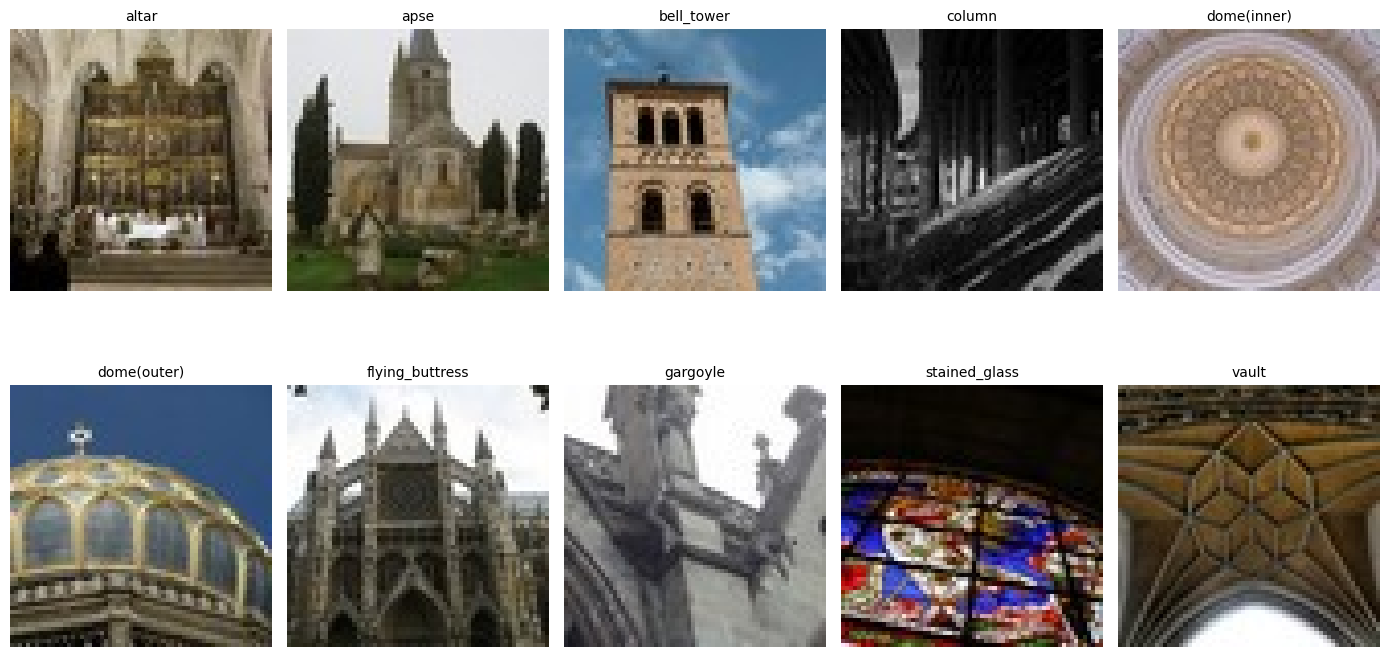

In [7]:
import matplotlib.image as mpimg #Matplotlib’in resim okuma/gösterme alt modülü.

train_root = "/content/data_raw/train"

# Sınıf isimlerini alır
classes = sorted([d for d in os.listdir(train_root) if os.path.isdir(os.path.join(train_root, d))])
print("Classes:", classes)

n = len(classes)

plt.figure(figsize=(14, 8))
for i, cls in enumerate(classes, 1):
    # Her sınıf klasöründen rastgele bir görsel seçer
    files = glob.glob(os.path.join(train_root, cls, "*"))
    sample = random.choice(files)
    img = mpimg.imread(sample)

    # Subplot'a yerleştirir
    plt.subplot(2, (n+1)//2, i)
    plt.imshow(img)
    plt.title(cls, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

### Train klasöründeki görsellerin dağılımı


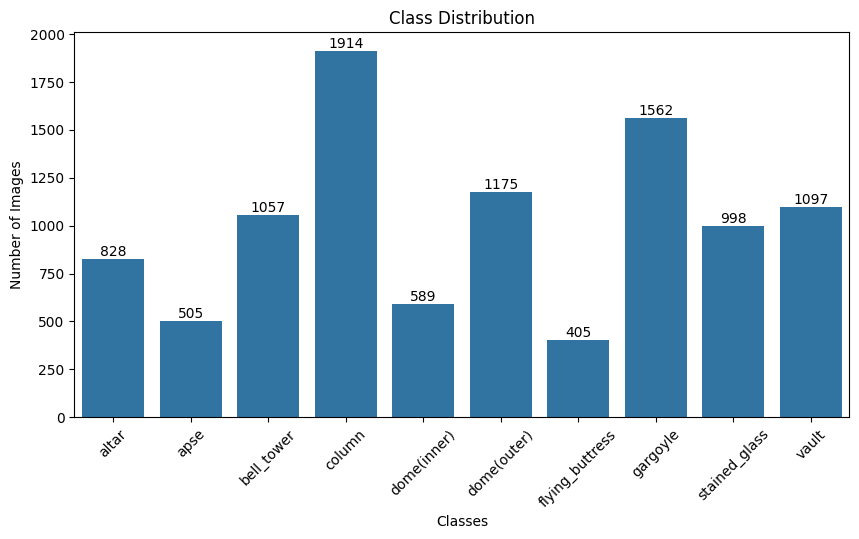

In [8]:
counts = {}
for cls in classes:
    path = os.path.join(train_root, cls)   # sınıfın klasör yolu
    counts[cls] = len(os.listdir(path))


plt.figure(figsize=(10, 5))
ax= sns.barplot(x=list(counts.keys()), y=list(counts.values()))

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10)

plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

# Bu adımda her sınıfta kaç adet görsel olduğu grafikte gösterildi


## Veri Ön İşleme


### Train & Test Veri Setinde Anormal Görsel Kontrolü


In [9]:
from PIL import Image

IMG_EXT = (".jpg", ".jpeg", ".png")   # izin verilen görsel uzantıları

def check_images(root, min_size=64):   #64x64'ten küçükse small
    broken, small = [], []
    for cls in os.listdir(root):
        class_path = os.path.join(root, cls)
        if not os.path.isdir(class_path):
            continue
        for file in glob.glob(os.path.join(class_path, "*")):
            if not file.lower().endswith(IMG_EXT):
                continue
            try:
                with Image.open(file) as img:
                    w, h = img.size
                    if w < min_size or h < min_size:
                        small.append((file, (w, h)))
            except Exception as e:
                broken.append((file, str(e)))
    return broken, small

# Train ve test için uygulanması
broken_train, small_train = check_images("/content/data_raw/train")
broken_test,  small_test  = check_images("/content/data_raw/test")

# Özet tablo
df_check = pd.DataFrame([
    {"Dataset": "Train", "Broken": len(broken_train), "Small": len(small_train)},
    {"Dataset": "Test",  "Broken": len(broken_test),  "Small": len(small_test)}
])

print(df_check)

  Dataset  Broken  Small
0   Train       0      0
1    Test       0      0


Train ve test setlerinde bozuk veya anormal boyutlu görsel kontrolü yapıldığında
her iki sette de bozuk ya da çok küçük (64x64 piksel altı) görsel bulunmamıştır.
Dolayısıyla veri seti bütünlüğü korunmuş ve ek temizlik adımı uygulanmamıştır.

### Görsellerin Boyutlandırılması ve Veri Ayrımı

Keras, `image_dataset_from_directory` fonksiyonu ile klasör yapısını okurken hem **train/validation/test ayrımını** yapabildiği hem de görselleri belirtilen boyuta dönüştürebildiği için işleme veri ayrımı ile başladım.  


In [10]:

# Yollar ve temel ayarlar
train_dir = "/content/data_raw/train"
test_dir  = "/content/data_raw/test"
IMG_SIZE  = (224, 224)
BATCH     = 32
SEED      = 42
AUTOTUNE  = tf.data.AUTOTUNE

# 1) Train → Train (%85) + Val (%15)
train_raw = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH,
    label_mode="categorical",
    validation_split=0.15,
    subset="training",
    seed=SEED,
    shuffle=True
)

val_raw = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH,
    label_mode="categorical",
    validation_split=0.15,
    subset="validation",
    seed=SEED,
    shuffle=False
)

# 2) Test set (Zaten ayrı klasörde olduğu için doğrudan yüklendi).
test_raw = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH,
    label_mode="categorical",
    shuffle=False
)

# 3) Normalize
def to_float(x):
    return tf.cast(x, tf.float32) / 255.0

def prep(ds):
    return ds.map(lambda x, y: (to_float(x), y), num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)

train_norm = prep(train_raw)
val_norm   = prep(val_raw)
test_norm  = prep(test_raw)

class_names = train_raw.class_names
num_classes = len(class_names)
print("Classes:", class_names, "| num_classes:", num_classes)

Found 10130 files belonging to 10 classes.
Using 8611 files for training.
Found 10130 files belonging to 10 classes.
Using 1519 files for validation.
Found 1404 files belonging to 10 classes.
Classes: ['altar', 'apse', 'bell_tower', 'column', 'dome(inner)', 'dome(outer)', 'flying_buttress', 'gargoyle', 'stained_glass', 'vault'] | num_classes: 10


## Veri Seti Dağılımı
- Toplamda 10 sınıfa ait 11.534 görsel bulunmaktadır.  
- Train klasöründeki 10.130 görsel, %85 / %15 oranında train ve validation olarak ayrılmıştır.  
  - Train: 8.611 görsel  
  - Validation: 1.519 görsel  
- Test klasörü ise ayrıca 1.404 görsel içermektedir.  




### Sınıflara Göre Görsel Sayı Dağılımı (Train–Validation–Test)


In [11]:

def count_images_in_dir(root):
    classes = sorted([d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))])
    counts = {}
    for cls in classes:
        path = os.path.join(root, cls)
        files = [f for f in glob.glob(os.path.join(path, "*")) if f.lower().endswith(IMG_EXT)]
        counts[cls] = len(files)
    return counts

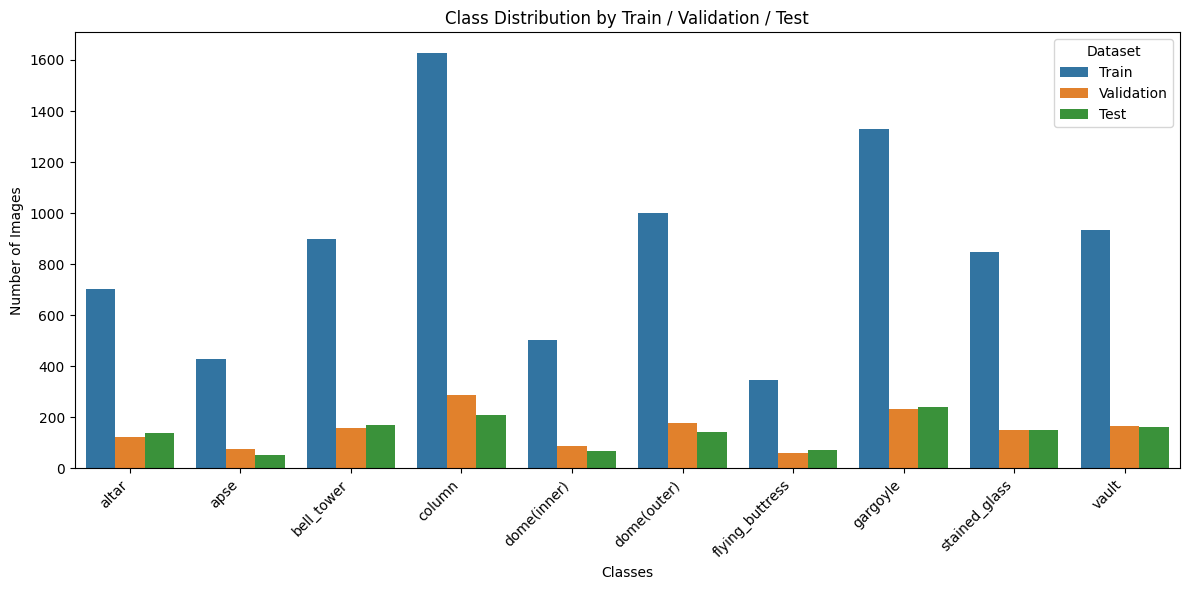

In [12]:
# Train ve test için sayıları alır
train_counts = count_images_in_dir("/content/data_raw/train")
test_counts  = count_images_in_dir("/content/data_raw/test")

# Validation sayısını train'in %15'i olarak hesaplar
val_counts = {cls: int(cnt * 0.15) for cls, cnt in train_counts.items()}
adj_train_counts = {cls: cnt - val_counts[cls] for cls, cnt in train_counts.items()}

# DataFrame'e dönüştürüldü
df = pd.DataFrame({
    "Class": list(train_counts.keys()) * 3,
    "Count": list(adj_train_counts.values()) + list(val_counts.values()) + list(test_counts.values()),
    "Split": ["Train"] * len(train_counts) + ["Validation"] * len(val_counts) + ["Test"] * len(test_counts)
})

# Barplot
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df, x="Class", y="Count", hue="Split")


plt.title("Class Distribution by Train / Validation / Test")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

Bu dağılım, hem modelin eğitim süreci için yeterli veri çeşitliliğini sağlamakta hem de validation ve test setlerinde her sınıf için dengeli bir değerlendirme yapılmasına imkân tanımaktadır. Çünkü train setinde öğrenme için yeterli sayıda örnek bulundurduğu için model karmaşık desenleri yakalayabilir. Validation ve test setlerinin birbirine yakın büyüklükte olması modelin genelleme performansının daha güvenilir ölçülmesini sağlar. Böylece eğitim sırasında validation sonuçları ile eğitim sonrası test sonuçları arasında büyük farklılıklar beklenmez ve modelin gerçek hayattaki başarısını daha doğru şekilde yansıtması mümkün olur.

Veri seti boyutunun ve çeşitliliğinin yeterli olması, ayrıca mimari öğelerin (altar, column vb.) düzenli, simetrik ve görsel olarak anlaşılabilir yapıda bulunması nedeniyle bu aşamada data augmentation uygulanmamıştır. Ancak model sonuçlarında overfitting veya genelleme problemi gözlemlenirse augmentation yöntemleri ilerleyen adımlarda değerlendirilecektir.

## Modelin Eğitilmesi

In [16]:
INPUT_SHAPE = (224, 224, 3)

def build_cnn(input_shape=INPUT_SHAPE, num_classes=10):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        # Block 1
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.30),

        # Classifier
        layers.GlobalAveragePooling2D(),    # L2 (1e-4): Dense katmanda overfitting’i sınırlamak için.
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.40),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_cnn(num_classes=num_classes)
model.summary()

EPOCHS = 20
ckpt = callbacks.ModelCheckpoint("/content/cnn_best.h5", monitor="val_accuracy",
                                 save_best_only=True, verbose=1)
early = callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                restore_best_weights=True, verbose=1)

history = model.fit(
    train_norm,                 # normalize edilmiş train ve validation
    validation_data=val_norm,
    epochs=EPOCHS,
    callbacks=[ckpt, early],
    verbose=1
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 157,226 (614.16 KB)

 Trainable params: 157,226 (614.16 KB)

 Non-trainable params: 0 (0.00 B)

...

270/270 ━━━━━━━━━━━━━━━━━━━━ 30s 111ms/step - accuracy: 0.5289 - loss: 1.3073 - val_accuracy: 0.5984 - val_loss: 1.0622
Epoch 7/20
269/270 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.5458 - loss: 1.2393
Epoch 7: val_accuracy improved from 0.59842 to 0.62146, saving model to /content/cnn_best.h5


270/270 ━━━━━━━━━━━━━━━━━━━━ 30s 112ms/step - accuracy: 0.5459 - loss: 1.2393 - val_accuracy: 0.6215 - val_loss: 0.9927
Epoch 8/20
269/270 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.5705 - loss: 1.2008
Epoch 8: val_accuracy did not improve from 0.62146
270/270 ━━━━━━━━━━━━━━━━━━━━ 30s 111ms/step - accuracy: 0.5705 - loss: 1.2008 - val_accuracy: 0.6169 - val_loss: 0.9529
Epoch 9/20
269/270 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.5944 - loss: 1.1502
Epoch 9: val_accuracy improved from 0.62146 to 0.68993, saving model to /content/cnn_best.h5


270/270 ━━━━━━━━━━━━━━━━━━━━ 30s 112ms/step - accuracy: 0.5943 - loss: 1.1502 - val_accuracy: 0.6899 - val_loss: 0.8664
Epoch 10/20
269/270 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.6114 - loss: 1.1074
Epoch 10: val_accuracy did not improve from 0.68993
270/270 ━━━━━━━━━━━━━━━━━━━━ 30s 111ms/step - accuracy: 0.6114 - loss: 1.1074 - val_accuracy: 0.6313 - val_loss: 0.9653
Epoch 11/20
269/270 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.6094 - loss: 1.0963
Epoch 11: val_accuracy did not improve from 0.68993
270/270 ━━━━━━━━━━━━━━━━━━━━ 30s 111ms/step - accuracy: 0.6094 - loss: 1.0962 - val_accuracy: 0.6392 - val_loss: 0.9146
Epoch 12/20
269/270 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.6275 - loss: 1.0557
Epoch 12: val_accuracy did not improve from 0.68993
270/270 ━━━━━━━━━━━━━━━━━━━━ 31s 113ms/step - accuracy: 0.6275 - loss: 1.0557 - val_accuracy: 0.6188 - val_loss: 0.9665
Epoch 13/20
269/270 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.6433 - loss: 1.0103
Epoch 13

270/270 ━━━━━━━━━━━━━━━━━━━━ 30s 113ms/step - accuracy: 0.6695 - loss: 0.9398 - val_accuracy: 0.7347 - val_loss: 0.7344
Epoch 16/20
269/270 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.6842 - loss: 0.8974
Epoch 16: val_accuracy improved from 0.73469 to 0.84200, saving model to /content/cnn_best.h5


270/270 ━━━━━━━━━━━━━━━━━━━━ 30s 112ms/step - accuracy: 0.6843 - loss: 0.8973 - val_accuracy: 0.8420 - val_loss: 0.4988
Epoch 17/20
269/270 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.6887 - loss: 0.8791
Epoch 17: val_accuracy did not improve from 0.84200
270/270 ━━━━━━━━━━━━━━━━━━━━ 30s 112ms/step - accuracy: 0.6888 - loss: 0.8790 - val_accuracy: 0.7860 - val_loss: 0.6812
Epoch 18/20
269/270 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.7041 - loss: 0.8432
Epoch 18: val_accuracy did not improve from 0.84200
270/270 ━━━━━━━━━━━━━━━━━━━━ 30s 111ms/step - accuracy: 0.7042 - loss: 0.8431 - val_accuracy: 0.7854 - val_loss: 0.7191
Epoch 19/20
269/270 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.7278 - loss: 0.8081
Epoch 19: val_accuracy did not improve from 0.84200
270/270 ━━━━━━━━━━━━━━━━━━━━ 30s 112ms/step - accuracy: 0.7278 - loss: 0.8081 - val_accuracy: 0.7814 - val_loss: 0.6802
Epoch 20/20
269/270 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.7200 - loss: 0.7925
Epoch 20

Not: 16.	epoch’ta model %68.4 train accuracy ve %84.2 validation accuracy ile en başarılı noktaya ulaşmıştır. Validation loss’un 0.4988 olması, modelin genelleme yeteneğinin güçlü olduğunu göstermektedir.

### Modelin Değerlendirilmesi

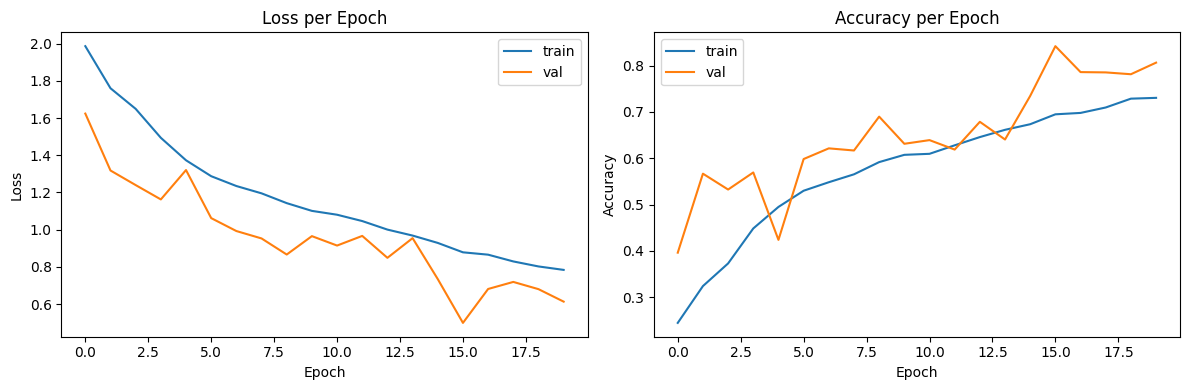

In [17]:
# Accuracy & Loss (epoch bazında)

plt.figure(figsize=(12,4))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss per Epoch'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy per Epoch'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.tight_layout(); plt.show()

Eğitim eğrisinde loss değerleri düzenli olarak azalırken, doğruluk (accuracy) değerleri artış göstermiştir. Validation tarafında dalgalanmalar gözlense de modelin genelleme yeteneği korunmuştur. En iyi epoch’ta doğruluk oranı %84.2 seviyesine kadar yükselmiştir. Bu yüksek değer, modelin doğrulama setinde güçlü bir genelleme performansı sergilediğini göstermektedir. Validation accuracy’de bazı dalgalanmalar olsa da, bu durum validation setinin görece küçük yapısından kaynaklanan doğal varyansla açıklanabilir. Genel eğri incelendiğinde train ve validation çizgilerinin birbirine yakın ilerlemesi, modelin aşırı uyum (overfitting) göstermediğini ve mimari öğeleri başarıyla ayırt edebildiğini ortaya koymaktadır.

                 precision    recall  f1-score   support

          altar       0.82      0.42      0.56       140
           apse       0.41      0.38      0.40        50
     bell_tower       0.55      0.28      0.37       170
         column       0.50      0.65      0.57       210
    dome(inner)       0.75      0.61      0.67        69
    dome(outer)       0.69      0.70      0.69       142
flying_buttress       0.45      0.27      0.34        70
       gargoyle       0.64      0.86      0.74       240
  stained_glass       0.95      0.91      0.93       150
          vault       0.62      0.84      0.71       163

       accuracy                           0.64      1404
      macro avg       0.64      0.59      0.60      1404
   weighted avg       0.65      0.64      0.63      1404

F1 (macro):    0.5974840843752625
F1 (weighted): 0.6273681898773327
F1 (micro):    0.6424501424501424


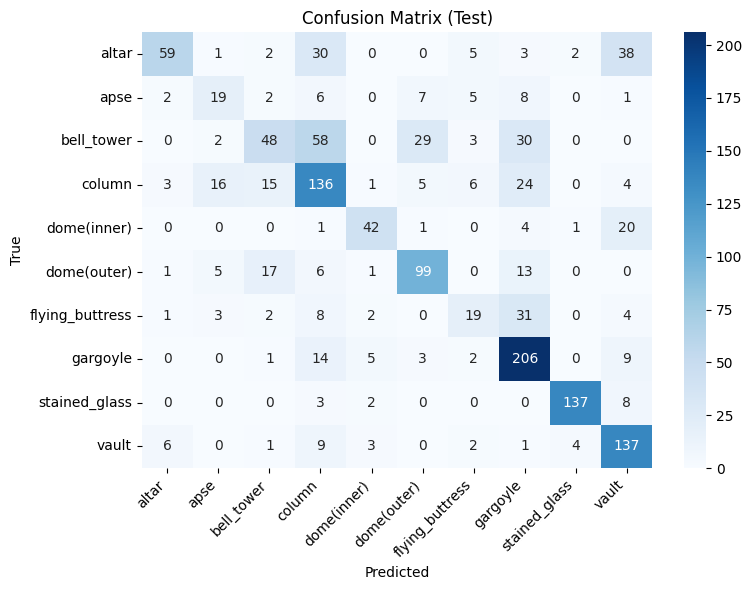

In [18]:
 # Confusion Matrix & Classification Report (+ F1)


y_batches = [y.numpy() for _, y in test_norm]
if y_batches[0].ndim > 1:  # one-hot
    y_true = np.concatenate(y_batches).argmax(axis=1)
else:                      # integer labels
    y_true = np.concatenate(y_batches)

y_pred = np.concatenate([model.predict(x, verbose=0) for x, _ in test_norm]).argmax(axis=1)

# Rapor
print(classification_report(y_true, y_pred, target_names=class_names))
print("F1 (macro):   ", f1_score(y_true, y_pred, average='macro'))
print("F1 (weighted):", f1_score(y_true, y_pred, average='weighted'))
print("F1 (micro):   ", f1_score(y_true, y_pred, average='micro'))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix (Test)')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

Modelin genel doğruluğu (accuracy = %64) olup, macro F1 ≈ 0.60 ve weighted F1 ≈ 0.63 seviyesindedir. Bu değerler, modelin sınıflar arasında dengeli bir performans sergilediğini ancak özellikle küçük örnek boyutuna sahip sınıflarda (ör. apse, flying buttress) sınırlı genelleme kabiliyetine ulaştığını göstermektedir.
	•	Yüksek performanslı sınıflar:
Stained glass (%93 F1) ve gargoyle (%74 F1) gibi görsel açıdan ayırt edici sınıflarda model yüksek precision ve recall değerleri elde etmiştir. Bu, modelin belirgin görsel özellikleri başarılı şekilde yakaladığını göstermektedir.
	•	Orta performanslı sınıflar:
Column, vault ve dome sınıflarında F1 skorları %57–71 arasında olup, model bu sınıfları görece tutarlı bir şekilde ayırt edebilmiştir.
	•	Düşük performanslı sınıflar:
Apse (%40 F1), bell tower (%37 F1) ve flying buttress (%34 F1) sınıflarında düşük başarı elde edilmiştir. Bu durum, hem sınıfların veri setindeki örnek sayısının sınırlı olması hem de görsel benzerliklerin yüksek olması ile ilişkilendirilebilir.

Genel olarak model, yüksek örnek sayısına ve belirgin görsel farklılıklara sahip sınıflarda yüksek başarı gösterirken, düşük örnekli ve görsel açıdan karmaşık sınıflarda zorluk yaşamaktadır.

Modelimde Grad-CAM görselleştirmesini kullanacağım için modelin graph’ının kurulması ve son Conv2D katman adının belirlenmesi gerekmektedir.

In [19]:
# Conv2D katman adının belirlenmesi
def last_conv_name(m):
    for lyr in reversed(m.layers):
        if isinstance(lyr, tf.keras.layers.Conv2D):
            return lyr.name
    raise ValueError("Conv2D bulunamadı.")

LAST_CONV = last_conv_name(model)
print(LAST_CONV)

conv2d_4


**Modelin Graph’ının Kurulması**

Grad-CAM ve benzeri görselleştirme yöntemlerinde, modelin ara katman çıkışlarına erişebilmek için modelin computational graph’ının inşa edilmiş olması gerekir. Sequential veya Functional API ile tanımlanan bir model, veriyle ilk kez çağrılmadan model.input ve model.output tensörlerini oluşturmaz.

Bu nedenle test_norm’dan küçük bir batch veya sahte (dummy) bir tensör kullanarak modeli bir kez çalıştırdık. Bu işlem, modelin tüm katmanlarını etkinleştirmiş ve giriş/çıkış tensörlerinin tanımlanmasını sağlamıştır. Böylece Grad-CAM gibi yöntemlerde ihtiyaç duyulan katman isimlerine ve ara çıktılara sorunsuz şekilde erişilebilmiştir.

In [20]:
# test_norm'dan küçük bir batch alıp modeli bir kez çağırıyoruz
sample_imgs, _ = next(iter(test_norm))
_ = model(sample_imgs[:1])
print("ready for Grad-CAM")

ready for Grad-CAM


/tmp/ipython-input-4181130115.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  overlay = (0.4 * cm.get_cmap('jet')(heat_resized)[..., :3] + 0.6 * imgs[i].numpy()).clip(0, 1)


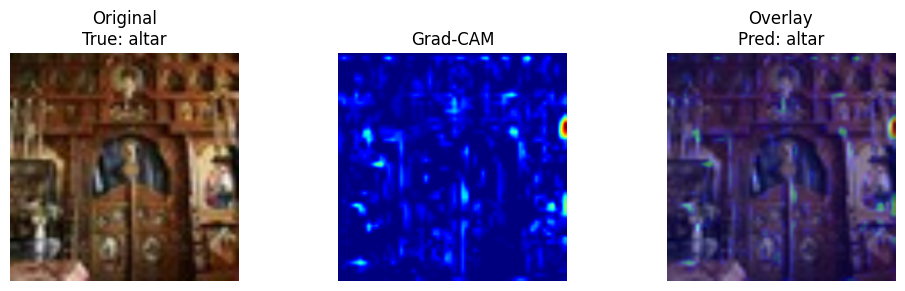

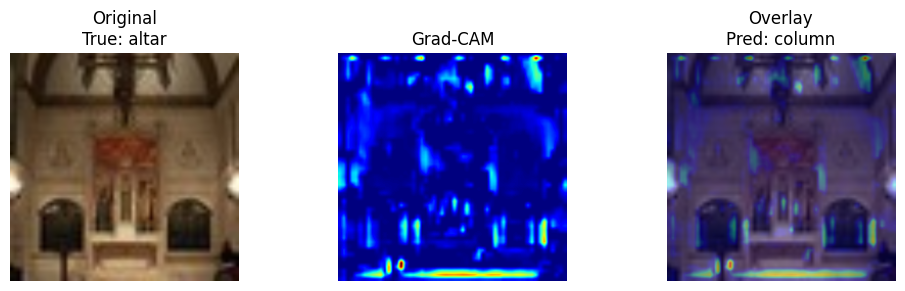

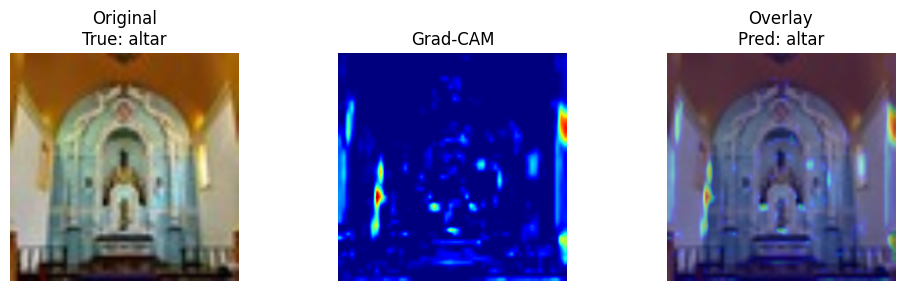

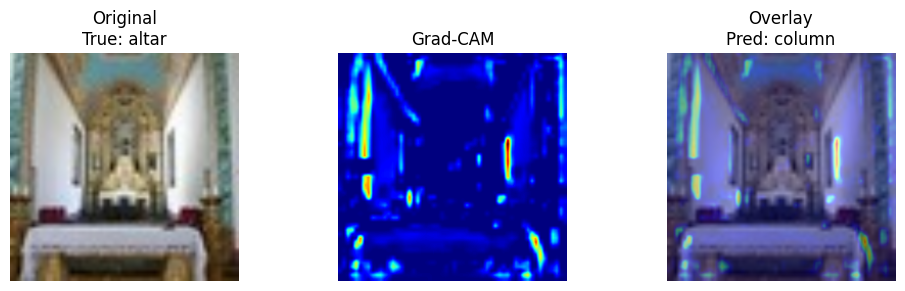

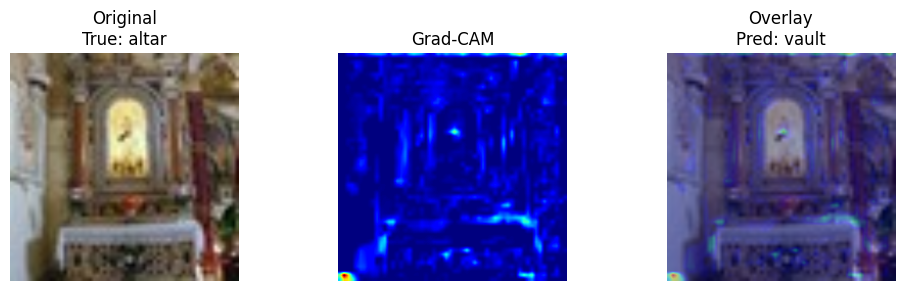

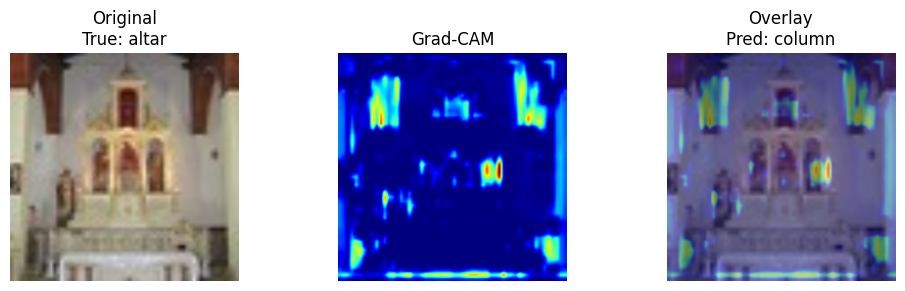

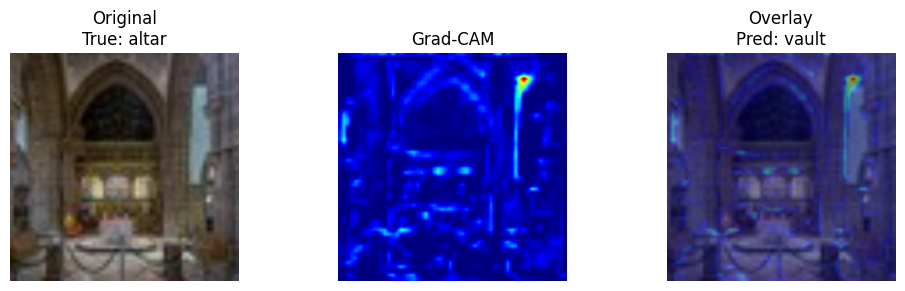

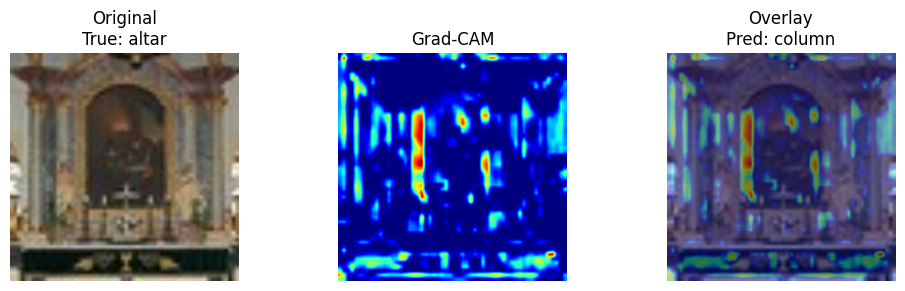

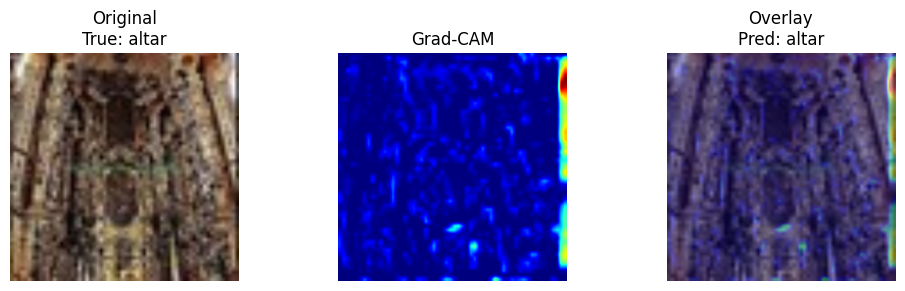

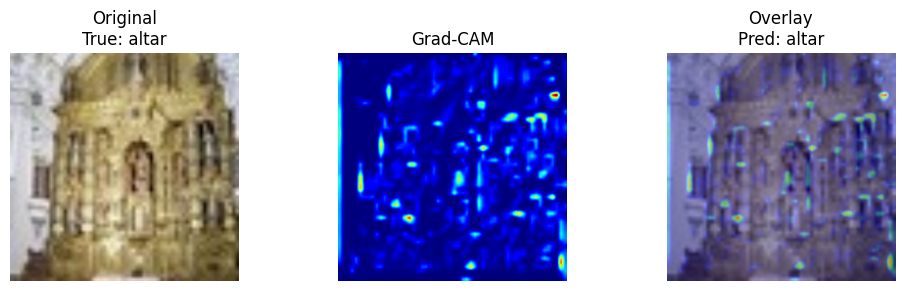

In [22]:

from matplotlib import cm

TARGET_CONV = LAST_CONV

def gradcam_one(model, img_batch, target_conv_name):
    """img_batch: (1,H,W,3), 0–1 normalize"""
    with tf.GradientTape() as tape:
        x = img_batch
        conv_act = None

        for layer in model.layers:
            x = layer(x)
            if layer.name == target_conv_name:
                conv_act = x  # (1,h',w',C)
        preds = x  # (1,num_classes)
        class_idx   = int(tf.argmax(preds[0]).numpy())
        class_score = preds[:, class_idx]

    # dY/dA: sınıf skorunun hedef conv aktivasyonuna gradyanı
    grads   = tape.gradient(class_score, conv_act)
    weights = tf.reduce_mean(grads, axis=(0,1,2))
    conv_map = conv_act[0]
    heatmap  = tf.reduce_sum(weights * conv_map, axis=-1)
    heatmap  = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), class_idx

def show_gradcam(dataset, n=3):
    imgs, labels = next(iter(dataset))
    imgs = imgs[:n]
    for i in range(n):
        x = tf.expand_dims(imgs[i], 0)   # (1,224,224,3)
        heat, pred_idx = gradcam_one(model, x, TARGET_CONV)

        # ısı haritasını görsel boyutuna ölçekle ve orijinal görselin üzerine uygula
        H, W = imgs.shape[1], imgs.shape[2]
        heat_resized = tf.image.resize(heat[..., None], (H, W)).numpy().squeeze()
        overlay = (0.4 * cm.get_cmap('jet')(heat_resized)[..., :3] + 0.6 * imgs[i].numpy()).clip(0, 1)

        true_idx = int(labels[i].numpy().argmax()) if labels.ndim>1 else int(labels[i].numpy())

        plt.figure(figsize=(10,3))
        plt.subplot(1,3,1); plt.imshow(imgs[i]); plt.title(f"Original\nTrue: {class_names[true_idx]}"); plt.axis('off')
        plt.subplot(1,3,2); plt.imshow(heat_resized, cmap='jet'); plt.title("Grad-CAM"); plt.axis('off')
        plt.subplot(1,3,3); plt.imshow(overlay); plt.title(f"Overlay\nPred: {class_names[pred_idx]}"); plt.axis('off')
        plt.tight_layout(); plt.show()


show_gradcam(test_norm, n=10)

Modelin karar verirken hangi bölgelerden etkilendiğini görselleştirmek için Grad-CAM yöntemini uyguladım.

	•	Önce son convolution katmanının aktivasyonları yakalanır.
	•	Daha sonra, modelin tahmin ettiği sınıfa ait skorun bu aktivasyonlara olan gradyanları hesaplanır.
	•	Gradyanların ortalaması alınarak  önem katsayıları elde edilir ve feature map’lerle çarpılarak ısı haritası üretilir.
	•	Son olarak, bu ısı haritası orijinal görüntü üzerine eklenerek modelin odaklandığı bölgeler görsel olarak sunulur.



  Grad-CAM görselleştirmeleri, modelin altar sınıfına ait örneklerde çoğunlukla doğru bölgeleri dikkate aldığını göstermektedir. Ancak bazı durumlarda model, altar yapısını sütun veya vault gibi benzer mimari öğelerle karıştırmıştır. Bu durum, özellikle görsellerde yapısal benzerlikler ve görsel karmaşıklık arttığında modelin sınıflar arası ayrımı yapmakta zorlandığını ortaya koymuştur.

###Hiperparametre Optimizasyonu

 Grid Search veya Bayesian Optimization gibi yöntemler de literatürde sıkça kullanılmakla birlikte, Grid Search tüm kombinasyonları denediği için oldukça zaman alıcıdır ve GPU süresi kısıtlı ortamlarda verimsizdir.

Random Search ise, belirlenen aralıklar içerisinden rastgele örnekler seçerek denemeler yaptığı için hem hızlıdır hem de kısa sürede makul sonuçlar elde etmeye imkân tanır. Sınırlı GPU kaynaklarını verimli kullanabilmek için **Random Search** yöntemini tercih ettim.

In [23]:


INPUT_SHAPE = (224, 224, 3)
NUM_CLASSES = 10

# Modeli tanımlayan fonksiyon
def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=INPUT_SHAPE))

    # 1. Conv Blok
    model.add(layers.Conv2D(
        filters=hp.Choice('conv1_filters', values=[32, 64]),
        kernel_size=3,
        padding="same",
        activation="relu"))
    model.add(layers.MaxPooling2D())
    model.add(layers.Dropout(hp.Choice('dropout1', values=[0.25, 0.3])))

    # Dense layer
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(
        units=hp.Choice('dense_units', values=[64, 128, 256]),
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.Dropout(hp.Choice('dropout2', values=[0.3, 0.4])))

    model.add(layers.Dense(NUM_CLASSES, activation="softmax"))

    # Optimizer learning rate seçimi
    lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"])
    return model


# RandomSearch Tuner
tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=5,   # toplam deneme sayısı
    executions_per_trial=1,
    directory="random_search",
    project_name="cnn_tuning")

# Tuning başlat
tuner.search(train_norm,
             validation_data=val_norm,
             epochs=5)   # hızlı görmek için 5 tercih ettim

# En iyi sonuç
best_model = tuner.get_best_models(num_models=1)[0]
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("En iyi hiperparametreler:")
print(f"Conv filters: {best_hps.get('conv1_filters')}")
print(f"Dense units: {best_hps.get('dense_units')}")
print(f"Dropout1: {best_hps.get('dropout1')}")
print(f"Dropout2: {best_hps.get('dropout2')}")
print(f"Learning Rate: {best_hps.get('learning_rate')}")

Trial 5 Complete [00h 00m 57s]
val_accuracy: 0.7412771582603455

Best val_accuracy So Far: 0.7412771582603455
Total elapsed time: 00h 04m 00s
En iyi hiperparametreler:
Conv filters: 64
Dense units: 128
Dropout1: 0.25
Dropout2: 0.3
Learning Rate: 0.01


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [24]:


INPUT_SHAPE = (224, 224, 3)
NUM_CLASSES = 10

best_hps = tuner.get_best_hyperparameters(1)[0]

def build_best():
    model = keras.Sequential([
        layers.Input(shape=INPUT_SHAPE),

        layers.Conv2D(best_hps.get('conv1_filters'), 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Dropout(best_hps.get('dropout1')),

        layers.GlobalAveragePooling2D(),
        layers.Dense(best_hps.get('dense_units'), activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(best_hps.get('dropout2')),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    lr = best_hps.get('learning_rate')   # tuner’ın bulduğu lr (0.01)
    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

best_model = build_best()
best_model.summary()

EPOCHS = 20
ckpt = callbacks.ModelCheckpoint('/content/cnn_best_tuned.keras',
                                 monitor='val_accuracy', save_best_only=True, verbose=1)
early = callbacks.EarlyStopping(monitor='val_loss', patience=5,
                                restore_best_weights=True, verbose=1)
plateau = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                      patience=2, min_lr=1e-5, verbose=1)

history_tuned = best_model.fit(
    train_norm, validation_data=val_norm,
    epochs=EPOCHS, callbacks=[ckpt, early, plateau], verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,402 (44.54 KB)

 Trainable params: 11,402 (44.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.2360 - loss: 2.0229
Epoch 1: val_accuracy improved from -inf to 0.40750, saving model to /content/cnn_best_tuned.keras
270/270 ━━━━━━━━━━━━━━━━━━━━ 16s 49ms/step - accuracy: 0.2361 - loss: 2.0225 - val_accuracy: 0.4075 - val_loss: 1.5063 - learning_rate: 0.0100
Epoch 2/20
269/270 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2920 - loss: 1.8220
Epoch 2: val_accuracy improved from 0.40750 to 0.43647, saving model to /content/cnn_best_tuned.keras
270/270 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.2921 - loss: 1.8218 - val_accuracy: 0.4365 - val_loss: 1.4482 - learning_rate: 0.0100
Epoch 3/20
269/270 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2950 - loss: 1.7898
Epoch 3: val_accuracy improved from 0.43647 to 0.51284, saving model to /content/cnn_best_tuned.keras
270/270 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.2951 - loss: 1.7896 - val_accuracy: 0.5128 - val_loss: 1.4058 - learning_rate: 0.0100
Epoch 4

In [25]:
test_loss, test_acc = best_model.evaluate(test_norm, verbose=0)
print(f"Test Accuracy (tuned): {test_acc:.4f}  |  Test Loss: {test_loss:.4f}")

Test Accuracy (tuned): 0.4010  |  Test Loss: 1.6156


Hiperparametre optimizasyonu kapsamında farklı kombinasyonlar test edilmiş;  Conv filtre sayısı, Dense katman boyutu, Dropout oranları ve Learning Rate üzerinde denemeler yapılmıştır. Yapılan **Random Search** denemelerinde en iyi model yaklaşık %74 validation accuracy değeri elde etmiş, ancak test setinde doğruluk oranı düşmüştür. Bu sonuç, seçilen parametrelerin overfitting veya validation setine aşırı uyum getirdiğini göstermektedir. Dolayısıyla, proje kapsamında en tutarlı ve genellenebilir sonuçları ilk kurduğum cnn model sağlamıştır.
